# Telco Customer Churn Prediction

## 📌 Overview
This project aims to predict customer churn in a telecom company using machine learning and identify key factors that influence customer retention.

## 🎯 Objectives

- Understand customer behavior and churn patterns  
- Build machine learning models to predict churn  
- Identify key drivers of churn  
- Provide actionable business insights  

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 📂 Load Dataset

In [2]:
df = pd.read_excel("/kaggle/input/datasets/myrazd/telco-customer-churn-xlsx/Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 🔍 Data Overview

In [3]:
# Check the size of the dataset.
df.shape

(7043, 33)

In [4]:
# Summary of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
# Statistics for numerical columns
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [6]:
# Spot potential issues
df.describe(include='all')

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
count,7043,7043.0,7043,7043,7043,7043.000000,7043,7043.000000,7043.000000,7043,...,7043,7043,7043,7043.000000,7043.0,7043,7043.000000,7043.000000,7043.000000,1869
unique,7043,NaN,1,1,1129,NaN,1652,NaN,NaN,2,...,3,2,4,NaN,6531.0,2,NaN,NaN,NaN,20
top,3186-AJIEK,NaN,United States,California,Los Angeles,NaN,"34.159534, -116.425984",NaN,NaN,Male,...,Month-to-month,Yes,Electronic check,NaN,20.2,No,NaN,NaN,NaN,Attitude of support person
freq,1,NaN,7043,7043,305,NaN,5,NaN,NaN,3555,...,3875,4171,2365,NaN,11.0,5174,NaN,NaN,NaN,192
mean,NaN,1.0,NaN,NaN,NaN,93521.964646,NaN,36.282441,-119.798880,NaN,...,NaN,NaN,NaN,64.761692,NaN,NaN,0.265370,58.699418,4400.295755,NaN
std,NaN,0.0,NaN,NaN,NaN,1865.794555,NaN,2.455723,2.157889,NaN,...,NaN,NaN,NaN,30.090047,NaN,NaN,0.441561,21.525131,1183.057152,NaN
min,NaN,1.0,NaN,NaN,NaN,90001.000000,NaN,32.555828,-124.301372,NaN,...,NaN,NaN,NaN,18.250000,NaN,NaN,0.000000,5.000000,2003.000000,NaN
25%,NaN,1.0,NaN,NaN,NaN,92102.000000,NaN,34.030915,-121.815412,NaN,...,NaN,NaN,NaN,35.500000,NaN,NaN,0.000000,40.000000,3469.000000,NaN
50%,NaN,1.0,NaN,NaN,NaN,93552.000000,NaN,36.391777,-119.730885,NaN,...,NaN,NaN,NaN,70.350000,NaN,NaN,0.000000,61.000000,4527.000000,NaN
75%,NaN,1.0,NaN,NaN,NaN,95351.000000,NaN,38.224869,-118.043237,NaN,...,NaN,NaN,NaN,89.850000,NaN,NaN,1.000000,75.000000,5380.500000,NaN


In [7]:
# Counts missing values in each column
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [8]:
# Check unique values
df.nunique()

CustomerID           7043
Count                   1
Country                 1
State                   1
City                 1129
Zip Code             1652
Lat Long             1652
Latitude             1652
Longitude            1651
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Tenure Months          73
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Monthly Charges      1585
Total Charges        6531
Churn Label             2
Churn Value             2
Churn Score            85
CLTV                 3438
Churn Reason           20
dtype: int64

In [9]:
# Look at target distribution
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
df['Churn Label'].value_counts(normalize=True)

Churn Label
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [11]:
# Check categorical values
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts().head(10))


Column: CustomerID
CustomerID
3186-AJIEK    1
3668-QPYBK    1
9237-HQITU    1
7203-OYKCT    1
9837-FWLCH    1
9710-NJERN    1
4807-IZYOZ    1
1471-GIQKQ    1
0666-UXTJO    1
9053-EJUNL    1
Name: count, dtype: int64

Column: Country
Country
United States    7043
Name: count, dtype: int64

Column: State
State
California    7043
Name: count, dtype: int64

Column: City
City
Los Angeles      305
San Diego        150
San Jose         112
Sacramento       108
San Francisco    104
Fresno            64
Long Beach        60
Oakland           52
Stockton          44
Bakersfield       40
Name: count, dtype: int64

Column: Lat Long
Lat Long
34.159534, -116.425984    5
33.28156, -115.955541     5
34.201108, -116.593456    5
33.798266, -118.300237    5
33.391181, -118.421305    5
33.989524, -118.089299    5
33.940619, -117.9513      5
33.976678, -118.065875    5
33.972119, -118.020188    5
33.867257, -118.330794    5
Name: count, dtype: int64

Column: Gender
Gender
Male      3555
Female    3488
Nam

In [12]:
# Check data types properly
df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

## 📝 Observations

- The dataset contains 7,043 customers with 33 features.

- The target variable is **`Churn Label`**, where around 26.5% of customers have churned and 73.5% have not. This indicates a moderately imbalanced dataset.

- The column **`Churn Reason`** has a large number of missing values (5,174), which likely corresponds to customers who did not churn.

- Some columns have incorrect data types. For example, **`Total Charges`** and **`Lat Long`** are stored as objects and may require conversion or further inspection.

- Most customers are **not senior citizens**, and the distribution between **male and female customers is fairly balanced**.

- A large portion of customers are on **month-to-month contracts**, which could potentially be linked to higher churn risk.

- **Fiber optic** is the most common internet service, followed by DSL and customers with no internet service.

- Many service-related features (such as online security, backup, and tech support) include a **“No internet service”** category, which will need to be handled carefully during preprocessing.

- **Paperless billing is more common** than traditional billing, and **electronic check** is the most frequently used payment method.

## 🧹 Data Cleaning

In [13]:
# Make a copy before cleaning
df_clean = df.copy()

In [14]:
# Clean column names
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

df_clean.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip_Code',
       'Lat_Long', 'Latitude', 'Longitude', 'Gender', 'Senior_Citizen',
       'Partner', 'Dependents', 'Tenure_Months', 'Phone_Service',
       'Multiple_Lines', 'Internet_Service', 'Online_Security',
       'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV',
       'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method',
       'Monthly_Charges', 'Total_Charges', 'Churn_Label', 'Churn_Value',
       'Churn_Score', 'CLTV', 'Churn_Reason'],
      dtype='object')

In [15]:
# Convert Total_Charges to numeric
df_clean["Total_Charges"] = pd.to_numeric(df_clean["Total_Charges"], errors="coerce")

df_clean["Total_Charges"].isnull().sum()

np.int64(11)

In [16]:
# Check rows where Total_Charges became missing
df_clean[df_clean["Total_Charges"].isnull()]

,CustomerID,Count,Country,State,City,Zip_Code,Lat_Long,Latitude,Longitude,Gender,...,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn_Label,Churn_Value,Churn_Score,CLTV,Churn_Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,...,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,...,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,...,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,...,Two year,No,Mailed check,25.75,NaN,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,...,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Two year,No,Mailed check,19.85,NaN,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,...,Two year,No,Mailed check,25.35,NaN,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,...,Two year,No,Mailed check,20.00,NaN,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,...,One year,Yes,Mailed check,19.70,NaN,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,...,Two year,No,Mailed check,73.35,NaN,No,0,44,2342,NaN


In [17]:
# Fill missing Total_Charges
df_clean["Total_Charges"] = df_clean["Total_Charges"].fillna(0)

df_clean["Total_Charges"].isnull().sum()

np.int64(0)

In [18]:
# Drop obvious irrelevant columns
cols_to_drop = [
    "CustomerID",
    "Lat_Long"
]

df_clean = df_clean.drop(columns=cols_to_drop, errors="ignore")

df_clean.head()

,Count,Country,State,City,Zip_Code,Latitude,Longitude,Gender,Senior_Citizen,Partner,...,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn_Label,Churn_Value,Churn_Score,CLTV,Churn_Reason
0,1,United States,California,Los Angeles,90003,33.964131,-118.272783,Male,No,No,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,1,United States,California,Los Angeles,90005,34.059281,-118.307420,Female,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,1,United States,California,Los Angeles,90006,34.048013,-118.293953,Female,No,No,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,1,United States,California,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,1,United States,California,Los Angeles,90015,34.039224,-118.266293,Male,No,No,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [19]:
# Keep Churn_Reason for EDA, but create a modeling version without it because it leaks information
df_model = df_clean.drop(columns=["Churn_Reason"], errors="ignore")

df_model.head()

,Count,Country,State,City,Zip_Code,Latitude,Longitude,Gender,Senior_Citizen,Partner,...,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn_Label,Churn_Value,Churn_Score,CLTV
0,1,United States,California,Los Angeles,90003,33.964131,-118.272783,Male,No,No,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239
1,1,United States,California,Los Angeles,90005,34.059281,-118.307420,Female,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701
2,1,United States,California,Los Angeles,90006,34.048013,-118.293953,Female,No,No,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372
3,1,United States,California,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003
4,1,United States,California,Los Angeles,90015,34.039224,-118.266293,Male,No,No,...,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340


In [20]:
# Final check after cleaning
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Count              7043 non-null   int64  
 1   Country            7043 non-null   object 
 2   State              7043 non-null   object 
 3   City               7043 non-null   object 
 4   Zip_Code           7043 non-null   int64  
 5   Latitude           7043 non-null   float64
 6   Longitude          7043 non-null   float64
 7   Gender             7043 non-null   object 
 8   Senior_Citizen     7043 non-null   object 
 9   Partner            7043 non-null   object 
 10  Dependents         7043 non-null   object 
 11  Tenure_Months      7043 non-null   int64  
 12  Phone_Service      7043 non-null   object 
 13  Multiple_Lines     7043 non-null   object 
 14  Internet_Service   7043 non-null   object 
 15  Online_Security    7043 non-null   object 
 16  Online_Backup      7043 

In [21]:
df_clean.isnull().sum().sort_values(ascending=False)

Churn_Reason         5174
Country                 0
Count                   0
City                    0
Zip_Code                0
Latitude                0
State                   0
Gender                  0
Senior_Citizen          0
Partner                 0
Dependents              0
Tenure_Months           0
Phone_Service           0
Multiple_Lines          0
Longitude               0
Internet_Service        0
Online_Security         0
Device_Protection       0
Online_Backup           0
Streaming_TV            0
Streaming_Movies        0
Contract                0
Tech_Support            0
Paperless_Billing       0
Payment_Method          0
Total_Charges           0
Monthly_Charges         0
Churn_Label             0
Churn_Value             0
Churn_Score             0
CLTV                    0
dtype: int64

In [22]:
df_clean.head()

,Count,Country,State,City,Zip_Code,Latitude,Longitude,Gender,Senior_Citizen,Partner,...,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn_Label,Churn_Value,Churn_Score,CLTV,Churn_Reason
0,1,United States,California,Los Angeles,90003,33.964131,-118.272783,Male,No,No,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,1,United States,California,Los Angeles,90005,34.059281,-118.307420,Female,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,1,United States,California,Los Angeles,90006,34.048013,-118.293953,Female,No,No,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,1,United States,California,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,1,United States,California,Los Angeles,90015,34.039224,-118.266293,Male,No,No,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


### Cleaning Notes

- Column names were standardized by replacing spaces with underscores.
  
- `Total_Charges` was converted from object to numeric.

- Missing values in `Total_Charges` were filled with 0, as these records are likely linked to new customers with no accumulated charges yet.

- `CustomerID` and `Lat_Long` were removed because they are not useful for the current churn analysis.

- `Churn_Reason` was kept for exploratory analysis but will be excluded from modeling to avoid data leakage.

## 📊 Exploratory Data Analysis

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

### Churn Distribution

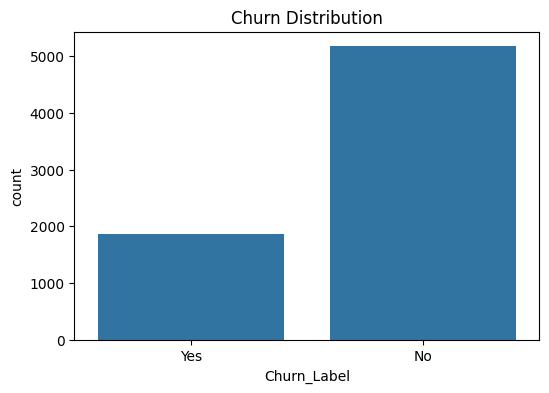

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn_Label', data=df_clean)
plt.title("Churn Distribution")
plt.show()

**Insight:**

The dataset is moderately imbalanced, with a larger proportion of customers who did not churn compared to those who did. This suggests that model evaluation should consider metrics beyond accuracy, such as recall and F1-score, to better capture churn behavior.

### Churn vs Contract Type

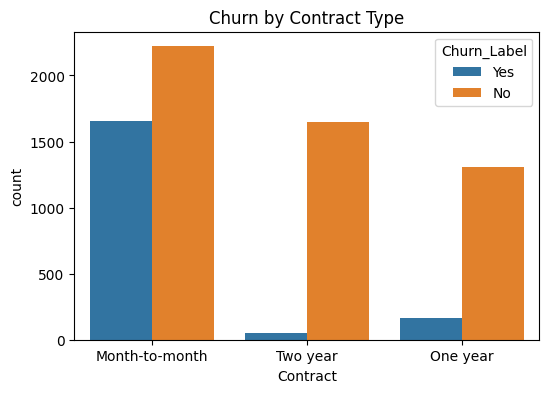

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x='Contract', hue='Churn_Label', data=df_clean)
plt.title("Churn by Contract Type")
plt.show()

In [26]:
pd.crosstab(df_clean['Contract'], df_clean['Churn_Label'], normalize='index')

Churn_Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


**Insight:**

Customers on month-to-month contracts show a significantly higher churn rate compared to those on one-year or two-year contracts. This suggests that longer contract commitments are associated with better customer retention.

### Churn vs Tenure

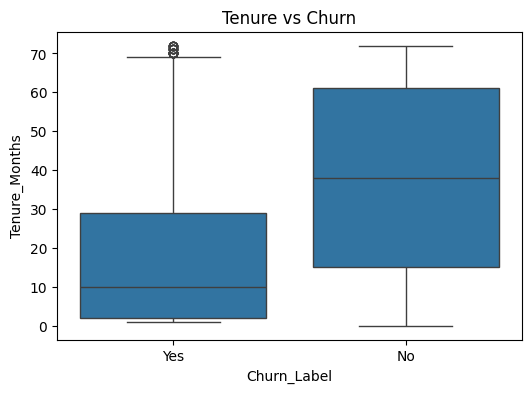

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn_Label', y='Tenure_Months', data=df_clean)
plt.title("Tenure vs Churn")
plt.show()

**Insight:**

Customers who churn tend to have shorter tenure compared to those who stay. This indicates that customers are more likely to leave early in their lifecycle, highlighting the importance of early engagement and retention strategies.

### Churn vs Monthly Charges

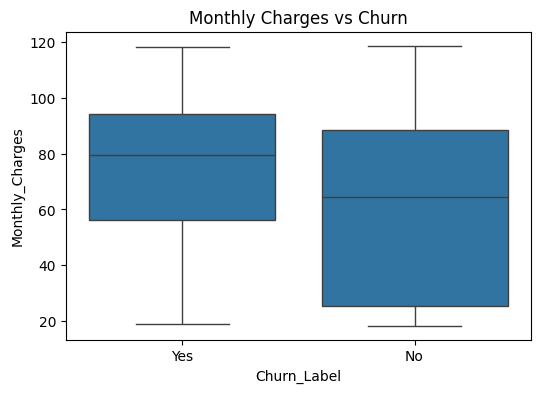

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn_Label', y='Monthly_Charges', data=df_clean)
plt.title("Monthly Charges vs Churn")
plt.show()

**Insight:**

Customers with higher monthly charges appear to have a higher likelihood of churning. This may indicate that pricing plays a role in customer dissatisfaction or perceived value.

### Churn vs Internet Service

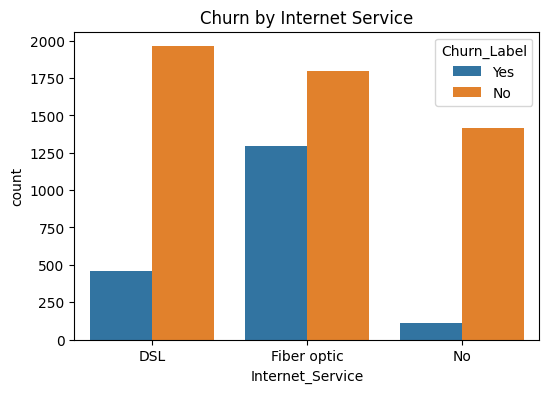

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(x='Internet_Service', hue='Churn_Label', data=df_clean)
plt.title("Churn by Internet Service")
plt.show()

**Insight:**

Customers using fiber optic internet appear to have a higher churn rate compared to DSL and those without internet service. This could suggest issues related to pricing, service quality, or customer expectations.

### Churn vs Payment Method

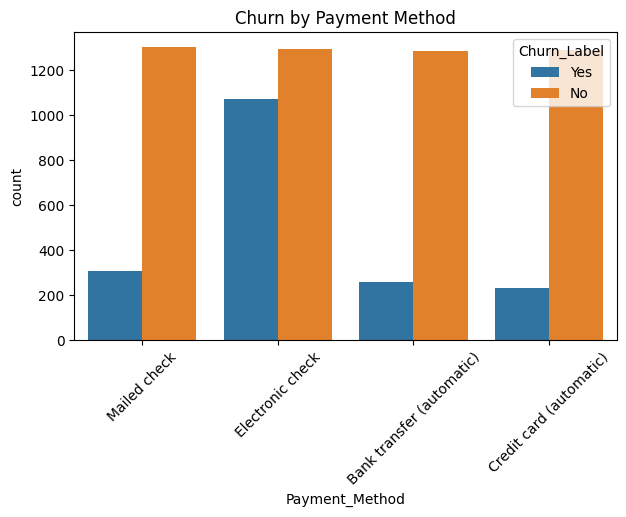

In [30]:
plt.figure(figsize=(7,4))
sns.countplot(x='Payment_Method', hue='Churn_Label', data=df_clean)
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

In [31]:
pd.crosstab(df_clean['Payment_Method'], df_clean['Churn_Label'], normalize='index')

Churn_Label,No,Yes
Payment_Method,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


**Insight:**

Customers using electronic check show a higher churn rate compared to other payment methods. This may indicate that customers who are less automated in their payments are also less committed or more likely to discontinue the service.

### Churn vs Tech Support

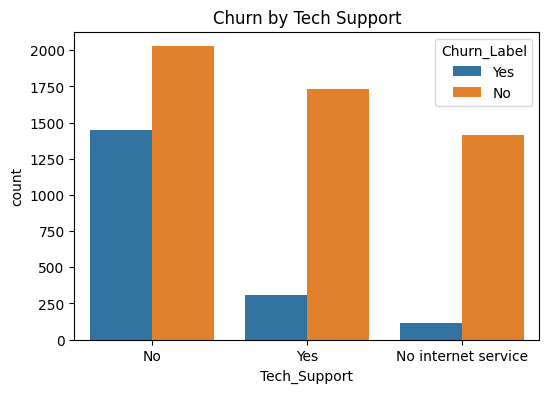

In [32]:
plt.figure(figsize=(6,4))
sns.countplot(x='Tech_Support', hue='Churn_Label', data=df_clean)
plt.title("Churn by Tech Support")
plt.show()

In [33]:
pd.crosstab(df_clean['Tech_Support'], df_clean['Churn_Label'], normalize='index')

Churn_Label,No,Yes
Tech_Support,,
No,0.583645,0.416355
No internet service,0.925950,0.074050
Yes,0.848337,0.151663


**Insight:**

Customers without tech support have a noticeably higher churn rate compared to those who have access to support services. This suggests that providing reliable customer support may play a key role in improving retention.

## 💡 Key EDA Insights

- Customers on **month-to-month contracts** have the highest churn rate, while those on longer-term contracts (one-year and two-year) are more likely to stay. This suggests that contract commitment plays a key role in retention.

- Customers with **shorter tenure** are more likely to churn, indicating that churn risk is highest early in the customer lifecycle.

- **Higher monthly charges** are associated with higher churn, which may reflect pricing sensitivity or perceived value issues.

- Customers using **fiber optic internet** show a higher churn rate compared to DSL and those without internet service, suggesting potential concerns around pricing or service experience.

- Customers who use **electronic check** as their payment method tend to churn more than those using automatic payment options, which may indicate lower engagement or commitment.

- Customers without **tech support services** are significantly more likely to churn, highlighting the importance of support services in customer retention.

## ⚙️ Data Preprocessing

In [34]:
# Separate features and target
X = df_model.drop("Churn_Label", axis=1)
y = df_model["Churn_Label"]

In [35]:
# Convert target to numeric
y = y.map({"Yes": 1, "No": 0})

In [36]:
# Handle categorical variables
X = pd.get_dummies(X, drop_first=True)

In [37]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
# Check shapes
print(X_train.shape)
print(X_test.shape)

(5634, 1165)
(1409, 1165)


In [39]:
# Scale numeric features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## ⚙️ Preprocessing Summary

### Preparing Features and Target

The target variable, `Churn_Label`, was converted into binary format:

- Yes → 1  
- No → 0  

All remaining columns were used as input features for model training.

---

### Encoding Categorical Variables

Categorical features were converted into numeric format using one-hot encoding with `pd.get_dummies()`.

For example, the `Contract` column was transformed into separate binary columns such as:

- `Contract_One year`
- `Contract_Two_year`

The `drop_first=True` option was used to avoid redundant columns and reduce multicollinearity.

---

### Train-Test Split

The dataset was split into training and testing sets using an 80:20 ratio.

Stratified sampling was applied to preserve the original churn distribution across both datasets.

## 🤖 Model Building

## 📈 Model Evaluation

## 💡 Key Insights

## 🧠 Business Recommendations

## ✅ Conclusion